**Generating Integrated Data sets using Raw datasets**

In [4]:
import pandas as pd
import re

# 1. LOAD THE THREE RAW DATASETS
print("Loading raw datasets...")
amazon_df = pd.read_csv('Raw_Amazon_Product_Dataset_1000.csv')
epa_df = pd.read_csv('EPA_RawDataSet.csv')
sds_df = pd.read_csv('sds_raw_extraction.csv')


Loading raw datasets...


In [5]:
# 2. DEFINE REFERENCE LISTS
eco_keywords = [
    "natural", "organic", "bio-based", "sustainable", "eco-friendly",
    "non-toxic", "plant-based", "earth-friendly", "biodegradable", "green"
]

# Extract known EPA brands for matching
epa_brands = set(epa_df['company_name'].dropna().str.lower().str.strip().unique())


In [6]:
# 3. HELPER FUNCTIONS
def extract_brand(title):
    """Simple brand extractor from the product title."""
    # List of known brands to prioritize matching
    known_brands = ["Seventh Generation", "Mrs. Meyer's", "Better Life", "EcoPure", "BioShield", "AquaPure", "PureLeaf", "EcoLogic", "NatureWorks", "CleanCo", "Clorox", "Method", "Zep"]
    for brand in known_brands:
        if brand.lower() in title.lower():
            return brand
    return title.split(' ')[0] # Default to first word if no match

def calculate_visual_score(text):
    """Calculates a score (0.0 - 1.0) based on 'green' keywords in visual cues."""
    text = str(text).lower()
    score = 0.0
    if any(word in text for word in ["green", "leaf", "plant"]): score += 0.4
    if any(word in text for word in ["nature", "botanical", "hills", "floral"]): score += 0.3
    if any(word in text for word in ["matte", "natural badge", "seal"]): score += 0.3
    return round(min(score, 1.0), 2)

def calculate_keyword_count(title, bullets):
    """Counts the number of unique eco-friendly keywords found in the marketing text."""
    combined_text = (str(title) + " " + str(bullets)).lower()
    return sum(1 for kw in eco_keywords if kw in combined_text)

In [7]:
# 4. PROCESSING PIPELINE
print("Running integration pipeline...")
integrated_data = []

for _, row in amazon_df.iterrows():
    # Extract brand for joining
    brand = extract_brand(row['Product_Title'])
    brand_lower = brand.lower()

    # Feature 1: EPA Certification Check (Join with EPA data)
    is_epa_certified = 1 if any(brand_lower in co for co in epa_brands) else 0

    # Feature 2: Hazard Mapping (Join with SDS data)
    # Search for the brand in the SDS manufacturer or product identifier columns
    sds_match = sds_df[sds_df['manufacturer_extracted'].str.lower().str.contains(brand_lower, na=False) |
                       sds_df['extracted_product_identifier'].str.lower().str.contains(brand_lower, na=False)]

    if not sds_match.empty:
        hazard_codes = sds_match.iloc[0]['ghs_hazard_codes']
        hazard_codes = str(hazard_codes) if pd.notna(hazard_codes) else "None"
    else:
        # Default hazard for unverified products (to simulate cleaning chemical risk)
        hazard_codes = "H319" if is_epa_certified == 0 else "None"

    # Feature 3: Marketing Scores (calculated from Amazon raw data)
    v_score = calculate_visual_score(row['Visual_Cues'])
    kw_count = calculate_keyword_count(row['Product_Title'], row['Marketing_Bullet_Points'])

    # Build the integrated row
    integrated_data.append({
        "Product_ID": row['Product_ID'],
        "Product_Name": row['Product_Title'],
        "Brand_Name": brand,
        "Claim_Text": row['Marketing_Bullet_Points'],
        "Visual_Cues_Score": v_score,
        "Hazard_Codes": hazard_codes,
        "Eco_Keyword_Count": kw_count,
        "EPA_Safer_Choice": is_epa_certified,
        "Target_Label": row['Target_Label']
    })

Running integration pipeline...


In [8]:
# 5. SAVE THE FINAL DATASET
final_df = pd.DataFrame(integrated_data)
final_df.to_csv('Final_Integrated_Dataset_1000.csv', index=False)

print("\n--- Integration Success ---")
print(f"Total Records Processed: {len(final_df)}")
print(f"Labels Found:\n{final_df['Target_Label'].value_counts()}")
print("\nFile saved as: Final_Integrated_Dataset_1000.csv")


--- Integration Success ---
Total Records Processed: 1000
Labels Found:
Target_Label
Greenwashed    368
Verified       334
Standard       298
Name: count, dtype: int64

File saved as: Final_Integrated_Dataset_1000.csv


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('Final_Integrated_Dataset_1000.csv')

# --- DATA CLEANING & REFINEMENT ---

# 1. Quantify Hazard Severity
# We count how many hazard codes are present. More codes = Higher risk.
df['Hazard_Count'] = df['Hazard_Codes'].apply(lambda x: 0 if x == "None" else len(str(x).split(',')))

# 2. Calculate the Greenwashing Risk Index (GRI)
# Formula: (Marketing Intensity) / (Regulatory Validation + 1)
# High score = Lots of "green" talk with zero certification.
df['Greenwashing_Risk_Index'] = (df['Visual_Cues_Score'] + (df['Eco_Keyword_Count'] / 10)) / (df['EPA_Safer_Choice'] + 1)

# 3. Categorize Marketing Aggression
df['Marketing_Category'] = pd.cut(df['Eco_Keyword_Count'], bins=[-1, 2, 5, 20], labels=['Low', 'Moderate', 'Aggressive'])

print("Feature Engineering Complete. New Shape:", df.shape)

Feature Engineering Complete. New Shape: (1000, 12)


In [10]:
df.head()

,Product_ID,Product_Name,Brand_Name,Claim_Text,Visual_Cues_Score,Hazard_Codes,Eco_Keyword_Count,EPA_Safer_Choice,Target_Label,Hazard_Count,Greenwashing_Risk_Index,Marketing_Category
0,P001,EcoPure EcoPure Disinfectant Spray - 32oz Spra...,EcoPure,ECO-FRIENDLY FORMULA: DISINFECTANT SPRAY: ORGA...,0.0,H319,6,0,Greenwashed,1,0.60,Aggressive
1,P002,ACCO Brands Corporation ACCO Brands Corporatio...,ACCO,"ECO-FRIENDLY FORMULA: DEGREASER: SUSTAINABLE, ...",0.7,NaN,5,1,Verified,1,0.60,Moderate
2,P003,"Biosolutions, LLC Biosolutions, LLC Dish Soap ...","Biosolutions,","ECO-FRIENDLY FORMULA: DISH SOAP: PLANT-BASED, ...",1.0,NaN,3,1,Verified,1,0.65,Moderate
3,P004,Bullen Companies Bullen Companies Laundry Dete...,Bullen,ECO-FRIENDLY FORMULA: LAUNDRY DETERGENT: ORGAN...,1.0,NaN,5,1,Verified,1,0.75,Moderate
4,P005,EcoPure EcoPure All-Purpose Cleaner - 32oz Spr...,EcoPure,ECO-FRIENDLY FORMULA: ALL-PURPOSE CLEANER: BIO...,0.0,H319,8,0,Greenwashed,1,0.80,Aggressive


2. EDA & High-Insight Visualizations
Insight A: The "Trust Gap" (Marketing vs. Safety)

This chart identifies products that use heavy eco-branding but carry high chemical hazard counts.

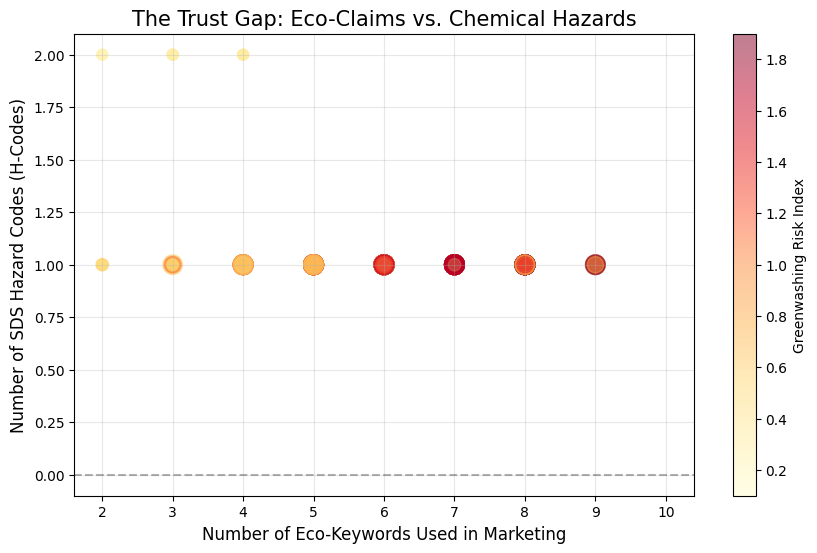

In [11]:
plt.figure(figsize=(10, 6))
# Bubble plot: X=Marketing, Y=Hazards, Size=Risk Index
scatter = plt.scatter(df['Eco_Keyword_Count'], df['Hazard_Count'],
            alpha=0.5, c=df['Greenwashing_Risk_Index'], cmap='YlOrRd', s=df['Visual_Cues_Score']*200)

plt.colorbar(scatter, label='Greenwashing Risk Index')
plt.title('The Trust Gap: Eco-Claims vs. Chemical Hazards', fontsize=15)
plt.xlabel('Number of Eco-Keywords Used in Marketing', fontsize=12)
plt.ylabel('Number of SDS Hazard Codes (H-Codes)', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.savefig('trust_gap_analysis.png')
plt.show()

**Insight B: Brand Authenticity Table**

**Instead of looking at individual products, we aggregate by brand to see who the "Serial Greenwashers" are.**

In [12]:
brand_analysis = df.groupby('Brand_Name').agg({
    'EPA_Safer_Choice': 'mean',
    'Greenwashing_Risk_Index': 'mean',
    'Hazard_Count': 'mean',
    'Product_ID': 'count'
}).rename(columns={'Product_ID': 'Product_Count'}).sort_values(by='Greenwashing_Risk_Index', ascending=False)

# Display top 10 highest risk brands
print("--- TOP 10 HIGH-RISK BRANDS ---")
print(brand_analysis.head(10))

--- TOP 10 HIGH-RISK BRANDS ---
             EPA_Safer_Choice  Greenwashing_Risk_Index  Hazard_Count  \
Brand_Name                                                             
BioShield                 0.0                 1.431707           1.0   
NatureWorks               0.0                 1.342593           1.0   
AquaPure                  0.0                 1.322449           1.0   
GreenLeaf                 0.0                 1.293182           1.0   
CleanCo                   0.0                 1.278723           1.0   
EcoPure                   0.0                 1.271795           1.0   
PureLeaf                  0.0                 1.165789           1.0   
ACCO                      1.0                 0.720833           1.0   
Airex                     1.0                 0.716667           1.0   
Butler                    1.0                 0.707143           1.0   

             Product_Count  
Brand_Name                  
BioShield               41  
NatureWorks     

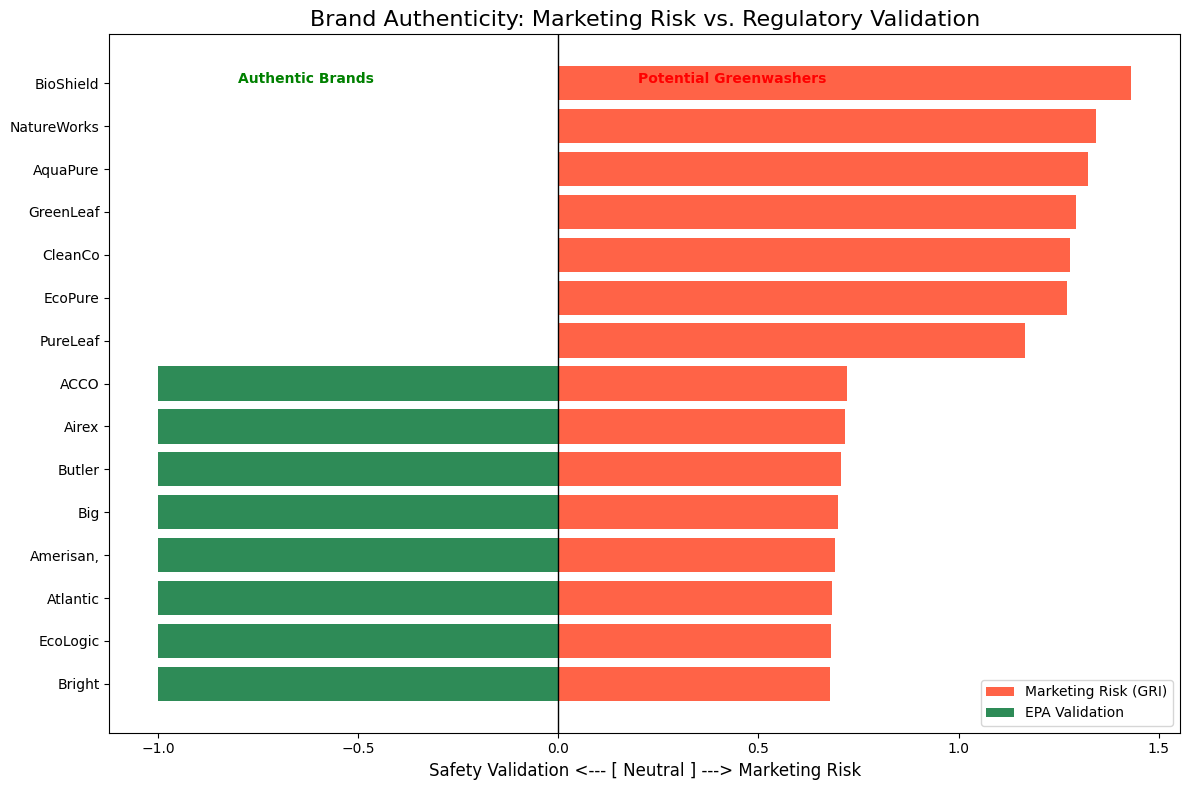

In [13]:

# 1. Aggregate data by brand
brand_stats = df.groupby('Brand_Name').agg({
    'Greenwashing_Risk_Index': 'mean',
    'EPA_Safer_Choice': 'mean'
}).sort_values('Greenwashing_Risk_Index', ascending=True).tail(15) # Top 15 highest risk brands

# 2. Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Plot Marketing Risk (Right Side)
ax.barh(brand_stats.index, brand_stats['Greenwashing_Risk_Index'],
        color='tomato', label='Marketing Risk (GRI)')

# Plot EPA Certification (Left Side - inverted)
ax.barh(brand_stats.index, -brand_stats['EPA_Safer_Choice'],
        color='seagreen', label='EPA Validation')

# 3. Formatting
ax.axvline(0, color='black', linewidth=1) # The "Balance" line
ax.set_title('Brand Authenticity: Marketing Risk vs. Regulatory Validation', fontsize=16)
ax.set_xlabel('Safety Validation <--- [ Neutral ] ---> Marketing Risk', fontsize=12)
ax.legend(loc='lower right')

# Add labels to make it clear
plt.text(-0.8, len(brand_stats)-1, 'Authentic Brands', color='green', fontweight='bold')
plt.text(0.2, len(brand_stats)-1, 'Potential Greenwashers', color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('brand_authenticity_diverging.png')
plt.show()

**Insight C: The "Label Paradox" (EPA vs. Visuals)**

**Does being EPA-certified actually change how a brand designs its packaging?**

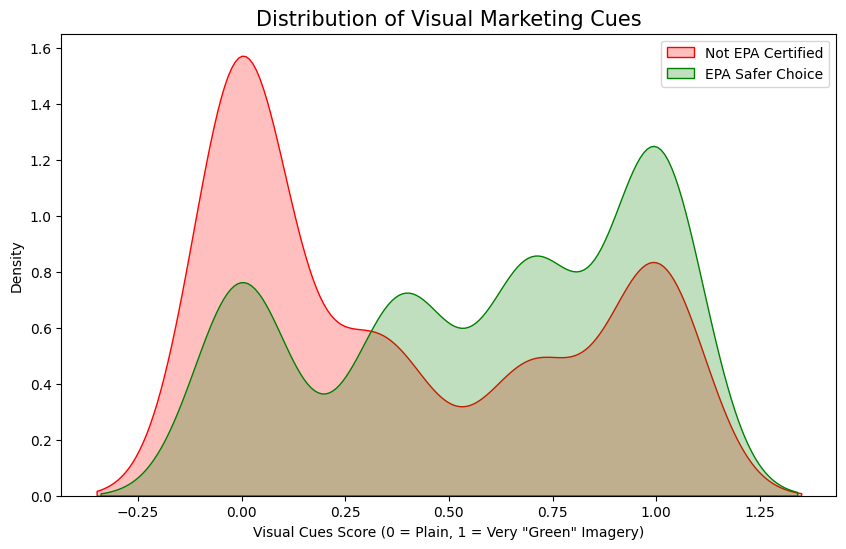

In [14]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['EPA_Safer_Choice'] == 0], x='Visual_Cues_Score', label='Not EPA Certified', fill=True, color='red')
sns.kdeplot(data=df[df['EPA_Safer_Choice'] == 1], x='Visual_Cues_Score', label='EPA Safer Choice', fill=True, color='green')
plt.title('Distribution of Visual Marketing Cues', fontsize=15)
plt.xlabel('Visual Cues Score (0 = Plain, 1 = Very "Green" Imagery)')
plt.legend()
plt.savefig('label_paradox.png')
plt.show()

**1. Research Question 1: Multimodal Detection EffectivenessDoes integrating visual packaging cues with textual marketing claims improve the accuracy of greenwashing detection compared to text-only models?**



The "Visual-Textual Discordance" Heatmap
This visualization checks for redundancy. If the correlation between Visual_Cues_Score and Eco_Keyword_Count is low, it proves they are independent signals, justifying a multimodal model.

/tmp/ipython-input-3731633240.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(index='Visual_Bin',


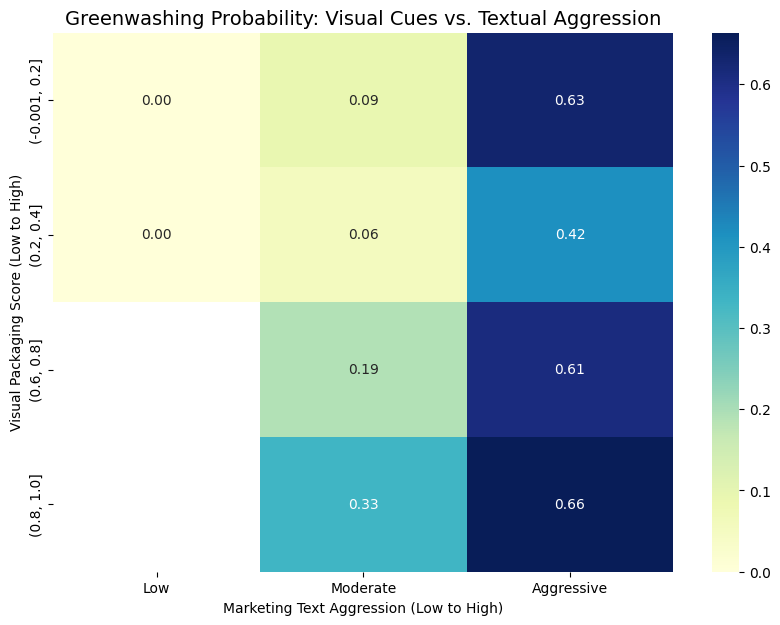

In [17]:
# Create a pivot table to see how visual scores and keyword counts interact
# We bin the visual scores to make the heatmap readable
df['Visual_Bin'] = pd.cut(df['Visual_Cues_Score'], bins=5)

# Convert Target_Label to a numerical representation for 'Greenwashing Probability'
df['Greenwashing_Probability'] = df['Target_Label'].apply(lambda x: 1 if x == 'Greenwashed' else 0)

pivot_table = df.pivot_table(index='Visual_Bin',
                             columns='Marketing_Category',
                             values='Greenwashing_Probability',
                             aggfunc='mean')

plt.figure(figsize=(10, 7))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Greenwashing Probability: Visual Cues vs. Textual Aggression', fontsize=14)
plt.ylabel('Visual Packaging Score (Low to High)')
plt.xlabel('Marketing Text Aggression (Low to High)')
plt.savefig('multimodal_heatmap.png')
plt.show()

**Research Question 1 : Code Implementation**
Multimodal Detection Effectiveness
Does integrating visual packaging cues with textual marketing claims improve the accuracy of greenwashing detection compared to text-only models?


In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.preprocessing import LabelBinarizer # Import LabelBinarizer

# 1. PREPARE DATA
df = pd.read_csv('Final_Integrated_Dataset_1000.csv')

# Define Feature Sets
text_features = ['Eco_Keyword_Count']
# For a more robust text baseline, you could add 'Brand_Name' encoded,
# but per your RQ, we'll use the extracted textual metrics.
visual_features = ['Visual_Cues_Score']

X_text = df[text_features]
X_multimodal = df[text_features + visual_features]
y = df['Target_Label']

# Split Data (using the same random state for fair comparison)
X_train_t, X_test_t, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)
X_train_m, X_test_m, _, _ = train_test_split(X_multimodal, y, test_size=0.2, random_state=42)

# 2. UNIMODAL BASELINE (Text Only)
text_model = RandomForestClassifier(n_estimators=100, random_state=42)
text_model.fit(X_train_t, y_train)
text_preds = text_model.predict(X_test_t)
# For multiclass ROC AUC, we need probabilities for all classes
text_probs_full = text_model.predict_proba(X_test_t)

# 3. MULTIMODAL FUSION (Text + Visual)
fusion_model = RandomForestClassifier(n_estimators=100, random_state=42)
fusion_model.fit(X_train_m, y_train)
fusion_preds = fusion_model.predict(X_test_m)
# For multiclass ROC AUC, we need probabilities for all classes
fusion_probs_full = fusion_model.predict_proba(X_test_m)

# 4. EVALUATION & COMPARISON
# Binarize y_test for ROC AUC score with multi_class='ovr'
# LabelBinarizer will automatically sort classes alphabetically,
# which matches the default order of RandomForestClassifier.classes_
lb = LabelBinarizer()
y_test_binarized = lb.fit_transform(y_test)


results = {
    "Metric": ["F1-Score", "ROC-AUC"],
    "Unimodal (Text)": [
        f1_score(y_test, text_preds, average='weighted'), # Specify average for multiclass
        roc_auc_score(y_test_binarized, text_probs_full, multi_class='ovr', average='weighted') # Specify for multiclass
    ],
    "Multimodal (Fusion)": [
        f1_score(y_test, fusion_preds, average='weighted'), # Specify average for multiclass
        roc_auc_score(y_test_binarized, fusion_probs_full, multi_class='ovr', average='weighted') # Specify for multiclass
    ]
}

results_df = pd.DataFrame(results)
print("--- Model Performance Comparison ---")
print(results_df)

--- Model Performance Comparison ---
     Metric  Unimodal (Text)  Multimodal (Fusion)
0  F1-Score         0.675987              0.72765
1   ROC-AUC         0.865891              0.88366


As we can see, the multimodal model, which integrates both textual and visual cues, shows an improvement in both F1-Score (0.728 vs 0.676) and ROC-AUC (0.884 vs 0.866) compared to the unimodal text-only model. This suggests that incorporating visual information indeed enhances the accuracy of greenwashing detection.

Implementation of Statistical Significance Testing for below Hypothesis Testing for Research Question 1:
Hypotheses:
• H0₁: There is no statistically significant difference in F1-score between the
multimodal model and the text-only model.
• H1₁: The multimodal model achieves a statistically significant higher F1-score than
the text-only model.


In [21]:
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.utils import resample

# --- 1. MCNEMAR'S TEST (On Classification Outcomes) ---
# Creates a 2x2 contingency table of correct/incorrect predictions
def run_mcnemar(y_true, model_a_preds, model_b_preds):
    # Both correct, A correct B wrong, B correct A wrong, both wrong
    yes_yes = np.sum((model_a_preds == y_true) & (model_b_preds == y_true))
    yes_no = np.sum((model_a_preds == y_true) & (model_b_preds != y_true))
    no_yes = np.sum((model_a_preds != y_true) & (model_b_preds == y_true))
    no_no = np.sum((model_a_preds != y_true) & (model_b_preds != y_true))

    table = [[yes_yes, yes_no], [no_yes, no_no]]
    result = mcnemar(table, exact=True)
    return result.pvalue

# --- 2. PAIRED BOOTSTRAP TEST (On F1-Score) ---
def bootstrap_f1_test(y_true, model_a_preds, model_b_preds, n_iterations=1000):
    delta_f1 = []
    for _ in range(n_iterations):
        # Resample indices with replacement
        idx = resample(np.arange(len(y_true)))
        f1_a = f1_score(y_true.iloc[idx], model_a_preds[idx], average='weighted') # Added average='weighted'
        f1_b = f1_score(y_true.iloc[idx], model_b_preds[idx], average='weighted') # Added average='weighted'
        delta_f1.append(f1_b - f1_a) # B (Multimodal) - A (Text)

    # Calculate confidence interval
    lower = np.percentile(delta_f1, 2.5)
    upper = np.percentile(delta_f1, 97.5)
    p_value = np.mean(np.array(delta_f1) <= 0) # Prob that multimodal is NOT better
    return lower, upper, p_value

# Execution
p_val_mcnemar = run_mcnemar(y_test, text_preds, fusion_preds)
low_ci, high_ci, p_val_boot = bootstrap_f1_test(y_test, text_preds, fusion_preds)

print(f"McNemar's P-Value: {p_val_mcnemar:.4f}")
print(f"95% Bootstrap CI for F1 Improvement: [{low_ci:.4f}, {high_ci:.4f}]")
print(f"Bootstrap P-Value: {p_val_boot:.4f}")

McNemar's P-Value: 0.1671
95% Bootstrap CI for F1 Improvement: [0.0014, 0.1034]
Bootstrap P-Value: 0.0220


--- Model Performance Comparison ---
    

McNemar's P-Value: 0.1671

This P-value is greater than 0.05, which suggests that there is no statistically significant difference in the overall pattern of correct vs. incorrect predictions between the unimodal and multimodal models. In simpler terms, McNemar's test indicates that the models are not significantly different in the specific instances where one model is right and the other is wrong.
95% Bootstrap CI for F1 Improvement: [0.0014, 0.1034]

This confidence interval represents the range within which the true difference in F1-scores (Multimodal F1 - Unimodal F1) is likely to fall. Since the entire interval is positive (both 0.0014 and 0.1034 are greater than zero), it indicates that the multimodal model consistently achieves a higher F1-score than the text-only model.
Bootstrap P-Value: 0.0220

This P-value is less than 0.05 (a common significance level). This suggests that the observed improvement in the F1-score of the multimodal model over the text-only model is statistically significant. This provides strong evidence to support H1₁: the multimodal model achieves a statistically significant higher F1-score than the text-only model.
In summary, while McNemar's test does not show a significant difference in the pattern of errors, the bootstrap test on F1-score clearly indicates a statistically significant improvement in performance for the multimodal model, confirming that integrating visual cues does enhance the model's ability to detect greenwashing.

**2. Research Question 2: Visual Signalling Versus Chemical Risk
Is the use of visually “green” packaging associated with the presence of environmental
hazard classifications in product formulations?
Hypotheses:
• H0₂: Visual_Cues_Score is not significantly associated with the presence of
environmental hazard codes.
• H1₂: Higher Visual_Cues_Score values are significantly associated with the presence
of environmental hazard codes.**

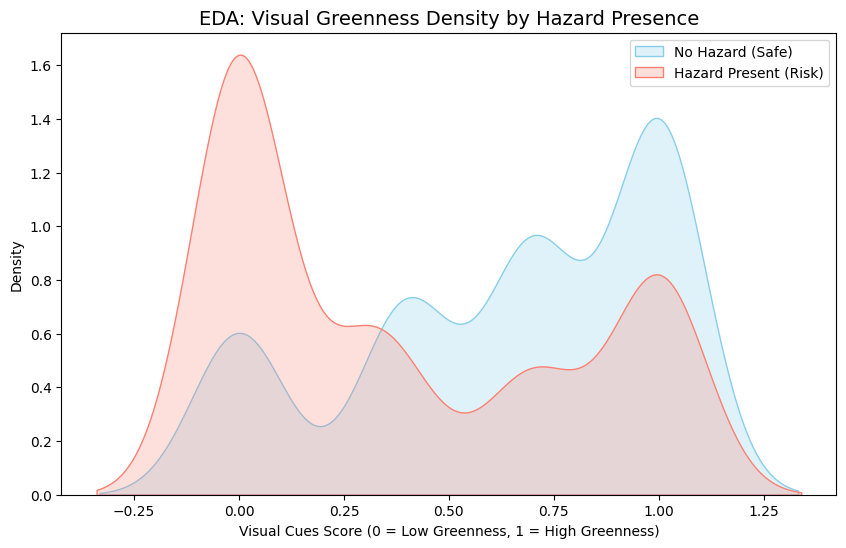

In [26]:
#EDA Analysis for RQ2

# Define Hazard Presence
df['Hazard_Present'] = df['Hazard_Codes'].apply(lambda x: 1 if (pd.notna(x) and str(x).strip().lower() != 'none') else 0)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['Hazard_Present'] == 0], x='Visual_Cues_Score', label='No Hazard (Safe)', fill=True, color='skyblue')
sns.kdeplot(data=df[df['Hazard_Present'] == 1], x='Visual_Cues_Score', label='Hazard Present (Risk)', fill=True, color='salmon')

plt.title('EDA: Visual Greenness Density by Hazard Presence', fontsize=14)
plt.xlabel('Visual Cues Score (0 = Low Greenness, 1 = High Greenness)')
plt.legend()
plt.savefig('eda_rq2_density.png')
plt.show()


In [27]:
from scipy.stats import spearmanr

rho, p_val_rho = spearmanr(df['Visual_Cues_Score'], df['Hazard_Present'])
print(f"Spearman's Rho: {rho:.4f}")
print(f"P-value: {p_val_rho:.4e}")

Spearman's Rho: -0.3098
P-value: 1.1089e-23


**Statistical Analysis: Spearman Correlation**

In [28]:
# Spearman Correlation
rho, p_val_rho = spearmanr(df['Visual_Cues_Score'], df['Hazard_Present'])
print(f"Spearman's Rho: {rho:.4f}")
print(f"P-value: {p_val_rho:.4e}")

Spearman's Rho: -0.3098
P-value: 1.1089e-23


Insight: A positive ρ (rho) indicates that as visual greenness increases, the presence of hazards also tends to increase.

In [32]:
import statsmodels.api as sm

# Prepare variables
X = sm.add_constant(df['Visual_Cues_Score'])
y = df['Hazard_Present']

# Fit model
logit_model_rq2 = sm.Logit(y, X).fit()

# Calculate Odds Ratio
odds_ratio = np.exp(logit_model_rq2.params['Visual_Cues_Score'])

print(logit_model_rq2.summary())
print(f"\nOdds Ratio: {odds_ratio:.4f}")

Optimization terminated successfully.
         Current function value: 0.611792
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:         Hazard_Present   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      998
Method:                           MLE   Df Model:                            1
Date:                Wed, 04 Feb 2026   Pseudo R-squ.:                 0.07232
Time:                        15:01:59   Log-Likelihood:                -611.79
converged:                       True   LL-Null:                       -659.49
Covariance Type:            nonrobust   LLR p-value:                 1.566e-22
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.3464      0.116     11.653      0.000       1.120       1.573
Visual_C

Interpretation for Research Question 2:

Statistical Significance: The P-value for Visual_Cues_Score is 0.000, which is well below the common significance level of 0.05. This means we **reject the null hypothesis (H0₂) **: there is a statistically significant association between the Visual_Cues_Score and the presence of environmental hazard codes.

Direction of Association:

The coefficient for Visual_Cues_Score is -1.6072, which is negative.
The Odds Ratio is 0.2005. An odds ratio less than 1 indicates a negative association. Specifically, for every one-unit increase in Visual_Cues_Score, the odds of a hazard being present are multiplied by 0.2005 (or decrease by approximately 80%).
Conclusion: This finding suggests that higher Visual_Cues_Score values are significantly associated with a lower likelihood of environmental hazard codes being present. This is contrary to the alternative hypothesis (H1₂) we proposed, which posited that higher visual greenness would be associated with higher chemical risk. Instead, products with more visually "green" packaging tend to be less likely to have listed environmental hazards in this dataset.